# 01. 데이터 수집 + EDA + 통계 검정

**Phase 1 — Step 1 (확장판)**

## 이 노트북의 역할

1. **yfinance**로 SPY, QQQ 일별 OHLCV 다운로드 (2009-01-01 ~ 2026-03-31)
2. 결측·이상치 점검 (보수적 기준)
3. 일별 log-return 분포 (히스토그램 + QQ-plot)
4. **ACF/PACF lag 1~30** — 자기상관 정량 확인
5. 분석 기간(2016-01-01~2025-12-31) 집중 통계
6. **정상성 검정 (ADF + KPSS)** — LSTM 입력 전제 검증
7. **정규화 판단 + Jarque-Bera 정규성 검정**
8. **Ljung-Box 검정** — 자기상관 종합 검정
9. **ARCH-LM 검정** — 변동성 클러스터링 공식 검정
10. **Lookback Window T 결정** — seq_len=126 통계적 검증

## 원본과의 차이

`01_data_download_and_eda.ipynb`의 모든 내용에 §7~§11 통계 검정 섹션을 추가한 확장판입니다.
작성: 하연 (통계 검정·EDA 파트 담당)

## §1. 환경 설정 로드

`00_setup_and_utils.ipynb`를 `%run`으로 실행하면 한글 폰트·시드·경로 상수·공통 import가 모두 현재 커널에 들어옵니다.

In [1]:
%run ./00_setup_and_utils.ipynb

[OK] scripts.setup import 완료 — BASE_DIR = /Users/hayeon/finance_project/시계열_Test/Phase1_LSTM
[OK] 한글 폰트 설정 완료: AppleGothic
[OK] 시드 고정 완료: SEED=42
[정보] PyTorch 버전: 2.11.0, CUDA 가용: False
[OK] 경로 상수 확인
  BASE_DIR      = /Users/hayeon/finance_project/시계열_Test/Phase1_LSTM
  RAW_DATA_DIR  = /Users/hayeon/finance_project/시계열_Test/Phase1_LSTM/results/raw_data
  SETTING_A_DIR = /Users/hayeon/finance_project/시계열_Test/Phase1_LSTM/results/setting_A
  SETTING_B_DIR = /Users/hayeon/finance_project/시계열_Test/Phase1_LSTM/results/setting_B
[OK] 공통 import + 표시 옵션 적용 완료
  pandas 2.3.3, numpy 2.4.4
  Phase 1 — LSTM 단독 베이스라인 / 환경 설정 완료
  한글 폰트  : AppleGothic
  시드       : 42
  결과 경로  : /Users/hayeon/finance_project/시계열_Test/Phase1_LSTM/results
  진실원     : scripts/setup.py


## §2. yfinance 다운로드

### 2.1 yfinance 가용성 확인

yfinance는 Yahoo Finance의 비공식 API입니다. 버전에 따라 반환 형식(MultiIndex 컬럼 여부)이 다르므로 코드에서 방어적으로 처리합니다.

### 2.2 다운로드 방침

- **티커**: SPY(S&P 500 ETF), QQQ(나스닥 100 ETF)
- **기간**: 2009-01-01 ~ 2026-03-31
- **간격**: `1d` (일별)
- **auto_adjust=False**: OHLC와 Adj Close를 **별도 컬럼으로 모두** 받기 위함. `True`면 Close가 이미 조정되어 구분 불가.
- **저장**: `results/raw_data/{ticker}.csv`

### 2.3 재현성 함정

yfinance의 과거 데이터는 가끔 이전 버전과 미세하게 다를 수 있습니다(Yahoo 내부 재조정). 한 번 다운받고 CSV로 저장한 뒤에는 CSV에서만 읽어 사용해 재현성을 확보합니다. CSV가 이미 있으면 다시 받지 않습니다.

In [ ]:
# yfinance import. 미설치 시 안내 메시지 출력.
try:
    import yfinance as yf
    print(f'[OK] yfinance 버전: {yf.__version__}')
except ImportError:
    print('[경고] yfinance가 설치되어 있지 않습니다.')
    print('       pip install yfinance')
    raise

[OK] yfinance 버전: 1.2.1


In [3]:
# 다운로드 파라미터
TICKERS = ['SPY', 'QQQ']
DOWNLOAD_START = '2009-01-01'
DOWNLOAD_END = '2026-03-31'


def download_one_ticker(ticker: str, start: str, end: str, save_dir: Path) -> pd.DataFrame:
    """단일 티커를 yfinance로 다운로드하고 CSV로 저장한다.

    이미 동일 경로에 CSV가 있으면 재다운로드하지 않고 읽어 반환한다.
    재현성 확보를 위한 캐싱 정책이다.

    Parameters
    ----------
    ticker : str
        Yahoo Finance 티커 (예: 'SPY', 'QQQ').
    start, end : str
        다운로드 기간 (YYYY-MM-DD).
    save_dir : Path
        CSV 저장 디렉토리.

    Returns
    -------
    pd.DataFrame
        인덱스가 date(DatetimeIndex)인 OHLCV + Adj Close 데이터프레임.
    """
    csv_path = save_dir / f'{ticker}.csv'

    # 캐시가 있으면 CSV에서 읽음 (재현성)
    if csv_path.exists():
        print(f'  [캐시] {ticker}: {csv_path.name} 이미 존재 → CSV에서 로드')
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        return df

    # yfinance 다운로드 (단일 티커, auto_adjust=False)
    print(f'  [다운로드] {ticker}: {start} ~ {end}')
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval='1d',
        auto_adjust=False,
        progress=False,
    )

    # yfinance 버전에 따라 MultiIndex 컬럼이 반환될 수 있음 → 평탄화
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if df.empty:
        raise RuntimeError(f'{ticker} 다운로드 결과가 비어 있습니다. 인터넷 연결/티커명 확인.')

    # 인덱스명 통일
    df.index.name = 'date'
    df.to_csv(csv_path)
    print(f'  [저장] {csv_path}  ({len(df)} 행)')
    return df


# 실제 다운로드 실행
raw_dict: Dict[str, pd.DataFrame] = {}
for tic in TICKERS:
    raw_dict[tic] = download_one_ticker(tic, DOWNLOAD_START, DOWNLOAD_END, RAW_DATA_DIR)

print()
for tic, df in raw_dict.items():
    print(f'[{tic}] 행수={len(df)}, 기간={df.index.min().date()} ~ {df.index.max().date()}')

  [캐시] SPY: SPY.csv 이미 존재 → CSV에서 로드
  [캐시] QQQ: QQQ.csv 이미 존재 → CSV에서 로드

[SPY] 행수=4336, 기간=2009-01-02 ~ 2026-03-30
[QQQ] 행수=4336, 기간=2009-01-02 ~ 2026-03-30


In [4]:
# 다운로드된 컬럼·자료형 확인 (SPY 기준, QQQ도 동일 포맷)
print('[SPY] 컬럼 구성:')
print(raw_dict['SPY'].dtypes)
print()
print('[SPY] 처음 3행:')
raw_dict['SPY'].head(3)

[SPY] 컬럼 구성:
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

[SPY] 처음 3행:


,Adj Close,Close,High,Low,Open,Volume
date,,,,,,
2009-01-02,67.981255,92.959999,93.440002,89.849998,90.440002,227566300
2009-01-05,67.900833,92.849998,93.660004,91.889999,92.629997,240349700
2009-01-06,68.354240,93.470001,94.449997,92.680000,93.639999,328260900


## §3. 결측·이상치 점검

### 점검 항목

1. **결측치**: 컬럼별 NaN 개수
2. **거래일 연속성**: NYSE 개장일 기준 중간에 비는 날짜가 있는지
3. **Adj Close 양수 여부**: 음수·0은 로그 수익률 계산 불가
4. **극단 이상치**: |log_return| > **5σ**인 날의 개수와 날짜

### 이상치 임계를 ±5σ로 잡는 이유 (보수적)

CLAUDE.md 지침: "데이터를 drop하거나 변형하는 기준은 최대한 보수적으로 잡을 것."

- ±3σ: 정상 분포 기준 ~0.27% 발생 → 2,520 영업일 기준 ~7일 → 너무 많이 걸림
- **±5σ**: 정상 분포 기준 ~6e-5% → 16년치에도 2~3일 이하 → 진짜 이상치만 포착
- **실제 수익률은 fat-tail**이므로 정상 분포 계산보다 훨씬 많이 걸릴 수 있음. 걸린 날은 **리포트만 하고 제거는 하지 않음** (COVID 2020-03-16, 금융위기 2009 등은 실제 사건)

In [5]:
def data_quality_report(ticker: str, df: pd.DataFrame) -> pd.DataFrame:
    """결측·음수/0·거래일 연속성을 점검한다.

    Returns
    -------
    pd.DataFrame
        점검 항목별 한 줄 요약.
    """
    # 1. 결측치
    n_missing = df.isna().sum().sum()

    # 2. Adj Close 양수 여부
    n_nonpositive = int((df['Adj Close'] <= 0).sum())

    # 3. 거래일 연속성 (index 차이 > 7일이면 이상)
    idx_diff = df.index.to_series().diff().dt.days
    gap_days = int((idx_diff > 7).sum())  # 일주일 이상 공백 (거래소 장기 휴장 외엔 없음)

    # 4. 중복 인덱스
    n_dup = int(df.index.duplicated().sum())

    return pd.DataFrame({
        '항목': ['결측치 총합', 'Adj Close ≤ 0 일수', '7일 이상 공백 구간', '중복 날짜'],
        '값': [n_missing, n_nonpositive, gap_days, n_dup],
    }).assign(ticker=ticker)


# 각 티커별 품질 리포트
quality_reports = pd.concat([data_quality_report(t, df) for t, df in raw_dict.items()])
quality_reports.pivot(index='항목', columns='ticker', values='값')

ticker,QQQ,SPY
항목,,
7일 이상 공백 구간,0,0
Adj Close ≤ 0 일수,0,0
결측치 총합,0,0
중복 날짜,0,0


**[§3-1 해석]** 결측치·음수 가격·날짜 공백·중복 날짜 모두 **0건** → 원본 데이터 품질에 이상 없음. 추가 정제 없이 다음 단계로 진행 가능.

In [6]:
# log-return 계산 (Adj Close 기준) — 원본 DataFrame에 컬럼 추가
for tic, df in raw_dict.items():
    df['log_return'] = np.log(df['Adj Close']).diff()

# ±5σ 이상치 검출 — **분석 기간 내에서만** 기준 통계 계산 (누수 방지)
ANALYSIS_START = '2016-01-01'
ANALYSIS_END = '2025-12-31'


def detect_extreme_outliers(df: pd.DataFrame, sigma_thresh: float = 5.0,
                            start: str = ANALYSIS_START, end: str = ANALYSIS_END) -> pd.DataFrame:
    """|log_return| > k*σ 인 날짜를 반환. σ는 분석 기간 내에서만 계산한다.

    누수 방지: 분석 시작 전(2016 이전) 데이터로 이상치 기준을 잡으면 안 된다.
    반대로 분석 기간 전체 데이터로 σ를 잡는 것은 허용되지만, 엄격한 Walk-Forward에서는
    각 fold별로 σ 재계산이 필요할 수 있다. 여기서는 EDA 목적이므로 분석 기간 전체를 쓴다.
    """
    sub = df.loc[start:end].copy()
    sigma = sub['log_return'].std()
    sub['abs_return'] = sub['log_return'].abs()
    mask = sub['abs_return'] > sigma_thresh * sigma
    return sub.loc[mask, ['Adj Close', 'log_return']].assign(sigma_used=sigma)


# 각 티커별 극단 이상치 날짜 출력
for tic, df in raw_dict.items():
    outliers = detect_extreme_outliers(df)
    print(f'[{tic}] |log_return| > 5σ 날짜 개수: {len(outliers)}')
    if not outliers.empty:
        print(outliers.head(20))
    print()

[SPY] |log_return| > 5σ 날짜 개수: 9
            Adj Close  log_return  sigma_used
date                                         
2020-03-09 250.609909   -0.081313    0.011370
2020-03-12 226.739685   -0.100569    0.011370
2020-03-13 246.122849    0.082028    0.011370
2020-03-16 219.191162   -0.115887    0.011370
2020-03-24 223.513504    0.086731    0.011370
2020-04-06 243.470215    0.065007    0.011370
2020-06-11 276.333160   -0.059377    0.011370
2025-04-04 499.553345   -0.060327    0.011370
2025-04-09 542.402161    0.099863    0.011370

[QQQ] |log_return| > 5σ 날짜 개수: 8
            Adj Close  log_return  sigma_used
date                                         
2020-03-09 186.547180   -0.071995    0.014101
2020-03-12 170.886719   -0.096171    0.014101
2020-03-13 185.361740    0.081308    0.014101
2020-03-16 163.157654   -0.127592    0.014101
2020-03-17 175.531815    0.073103    0.014101
2020-03-24 177.373871    0.074586    0.014101
2022-11-10 276.730072    0.071193    0.014101
2025-04-09 46

**[§3-2 해석]** SPY 9건, QQQ 8건이 ±5σ를 초과하며, 대부분 **COVID 충격(2020-03)** 및 **2025-04 관세 충격** 시기에 집중. 이는 데이터 오류가 아닌 실제 시장 사건이므로 제거하지 않는다. fat-tail이 실재함을 미리 보여주며, 이후 Jarque-Bera 비정규성 결과의 직관적 근거가 된다.

## §4. log-return 분포

### 확인 사항

1. **중앙 경향**: 일별 log-return은 0에 가까워야 함 (연 ~10% ÷ 252일 ≈ 0.04%)
2. **분산**: SPY보다 QQQ가 변동성이 크다면 이론과 일치 (기술주 집중)
3. **꼬리**: QQ-plot에서 S자 곡선 → fat-tail (정규분포 가정 위반)
4. **왜도·첨도**: 금융 수익률은 보통 음의 왜도(왼쪽 꼬리) + 높은 첨도(leptokurtic)

### 정규화 필요성 평가

log-return 자체가 이미 수준 차이를 제거한 정상화된 시계열입니다. 추가 StandardScaler 필요 여부는 시각화 후 결정합니다 — 분포가 매우 뾰족하면 학습 안정성을 위해 적용 가능.

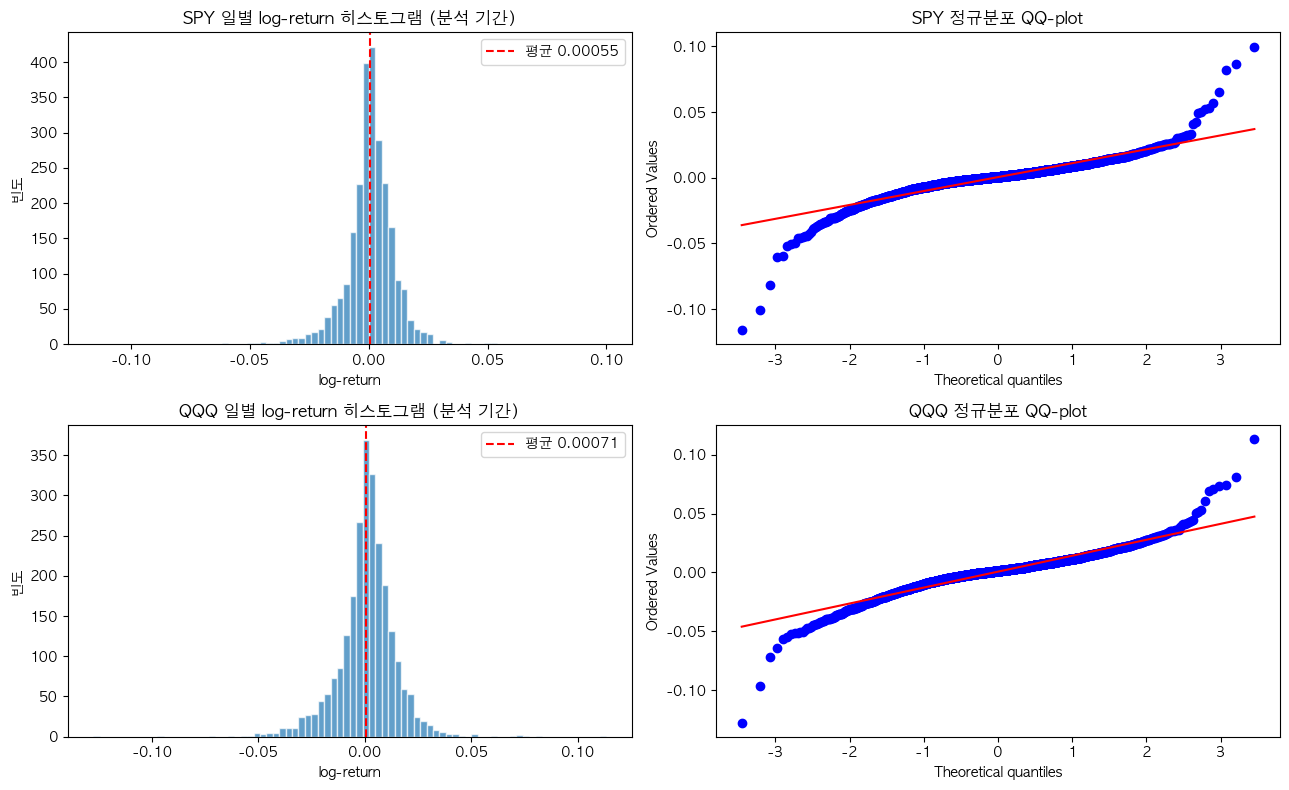

In [7]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, tic in enumerate(TICKERS):
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()

    # 히스토그램 (왼쪽)
    ax_hist = axes[row, 0]
    ax_hist.hist(lr, bins=80, edgecolor='white', alpha=0.7)
    ax_hist.axvline(lr.mean(), color='red', linestyle='--', label=f'평균 {lr.mean():.5f}')
    ax_hist.set_title(f'{tic} 일별 log-return 히스토그램 (분석 기간)')
    ax_hist.set_xlabel('log-return')
    ax_hist.set_ylabel('빈도')
    ax_hist.legend()

    # QQ-plot (오른쪽)
    ax_qq = axes[row, 1]
    stats.probplot(lr, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{tic} 정규분포 QQ-plot')

plt.tight_layout()
plt.show()

In [8]:
# 기술 통계 요약 (분석 기간 내)
stats_rows = []
for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    stats_rows.append({
        'ticker': tic,
        'n': len(lr),
        '평균': lr.mean(),
        '표준편차': lr.std(),
        '왜도': lr.skew(),
        '첨도(excess)': lr.kurt(),  # pandas는 excess kurtosis (정규분포 0 기준)
        '최소': lr.min(),
        '최대': lr.max(),
    })

pd.DataFrame(stats_rows).set_index('ticker')

,n,평균,표준편차,왜도,첨도(excess),최소,최대
ticker,,,,,,,
SPY,2514,0.000546,0.011370,-0.603658,15.137187,-0.115887,0.099863
QQQ,2514,0.000706,0.014101,-0.403158,7.891144,-0.127592,0.113356


**[§4 해석]**

| 지표 | SPY | QQQ | 해석 |
|---|---|---|---|
| 일평균 수익률 | 0.055%/일 | 0.071%/일 | 연 환산 약 14%·18%, 상승 추세 확인 |
| 표준편차(σ) | 1.14% | 1.41% | QQQ > SPY — 기술주 집중으로 인한 높은 변동성 (이론과 일치) |
| 왜도 | -0.60 | -0.40 | **음의 왜도** — 급락이 급등보다 극단적, 손실 리스크가 비대칭 |
| 초과 첨도 | 15.1 | 7.9 | **fat-tail 확정** — 정규분포(0) 대비 매우 높음 → Huber loss 채택의 직접 근거 |

SPY의 첨도가 QQQ보다 훨씬 높은 이유는 COVID 급락 충격(2020-03-16, -11.6%)의 상대적 영향이 더 크기 때문.

## §5. ACF / PACF — 자기상관 정량 확인 ⭐

### 이 섹션이 Phase 1에서 가장 중요한 이유

사용자 가설: "수익률의 자기상관이 극단적으로 작아 univariate LSTM으로는 성능이 안 나올 것"

이 가설을 **Phase 1 모델 학습 전에 정량적으로 확인**하는 것이 본 섹션의 목적입니다. ACF/PACF에서 모든 lag가 95% 신뢰구간 안에 있다면 "어떤 시계열 모델이라도 미래 수익률을 맞히기는 본질적으로 어렵다"는 사전 증거가 됩니다.

### ACF vs PACF

- **ACF** (Autocorrelation Function): lag k에서 `corr(r_t, r_{t-k})`. 간접 경로(중간 lag 거치는 것) 포함.
- **PACF** (Partial Autocorrelation Function): 중간 lag 효과를 걷어낸 순수 lag k 상관.
- **금융 수익률**: 대부분 ACF/PACF 모든 lag가 0에 가까움 (효율적 시장 가설 정합).
- **제곱/절댓값 수익률**: 변동성 클러스터링 → 강한 양의 자기상관 (GARCH 계열 모델의 근거)

### 95% 신뢰구간

`statsmodels.plot_acf`는 ±1.96/√n 을 95% 신뢰구간으로 표시합니다. 이 구간 밖의 lag는 통계적으로 유의한 자기상관이 있다는 뜻이지만, **통계적 유의 ≠ 경제적 의미**입니다. lag 1 ACF가 -0.05여도 t-검정에서 유의할 수 있지만 실제 예측력은 미미합니다.

### 추가: 절댓값·제곱 수익률 ACF

원 수익률 ACF는 작아도 변동성에는 구조가 있을 수 있습니다. Phase 1은 수익률 예측이 목적이므로 참고용으로만 확인합니다.

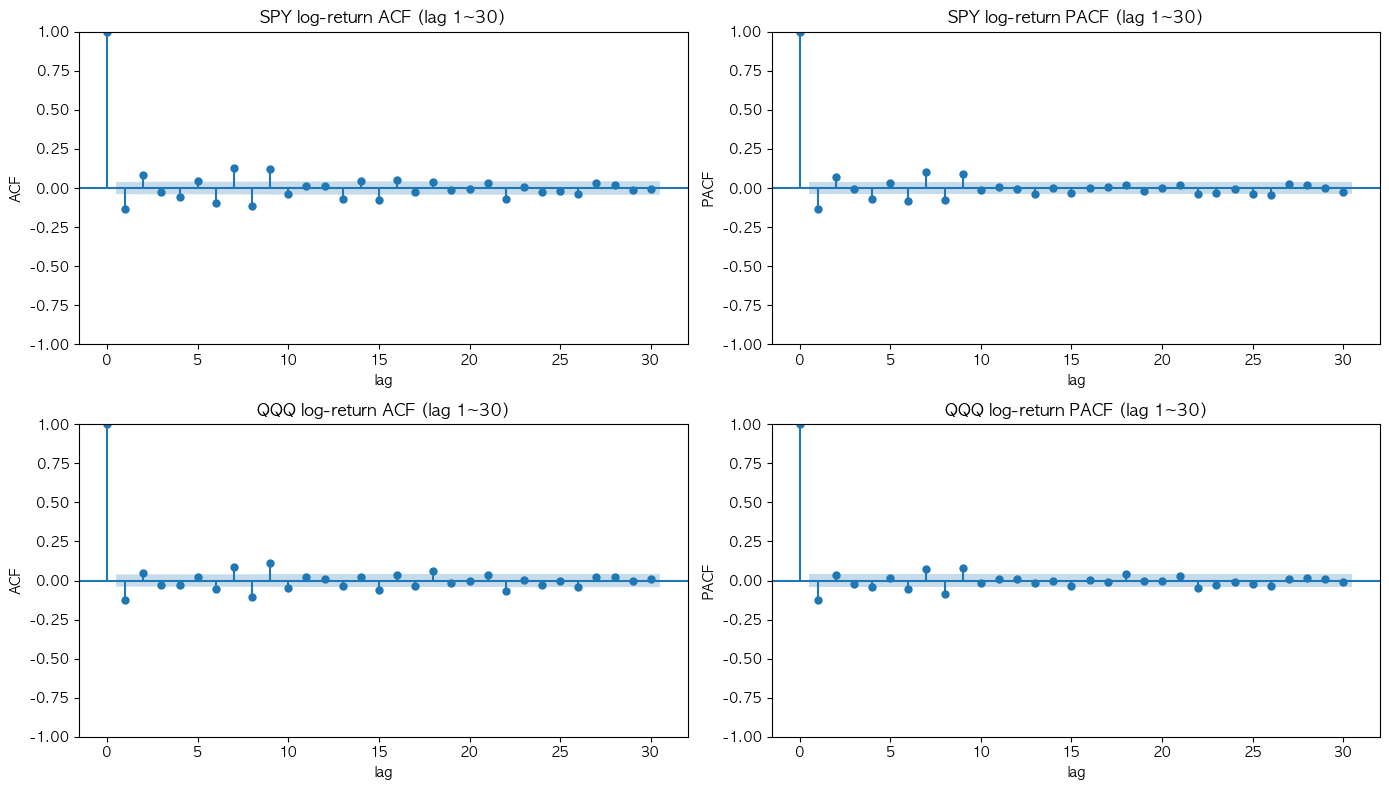

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

LAG_MAX = 30

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, tic in enumerate(TICKERS):
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()

    # ACF (왼쪽)
    plot_acf(lr, lags=LAG_MAX, ax=axes[row, 0], title=f'{tic} log-return ACF (lag 1~{LAG_MAX})')
    axes[row, 0].set_xlabel('lag')
    axes[row, 0].set_ylabel('ACF')

    # PACF (오른쪽)
    plot_pacf(lr, lags=LAG_MAX, ax=axes[row, 1], title=f'{tic} log-return PACF (lag 1~{LAG_MAX})', method='ywm')
    axes[row, 1].set_xlabel('lag')
    axes[row, 1].set_ylabel('PACF')

plt.tight_layout()
plt.show()

In [10]:
# lag 1~10 ACF 수치 직접 출력 (그래프 외 정량 확인용)
from statsmodels.tsa.stattools import acf

rows = []
for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    acf_values = acf(lr, nlags=10, fft=False)
    n = len(lr)
    ci_95 = 1.96 / np.sqrt(n)
    for lag in range(1, 11):
        rows.append({
            'ticker': tic,
            'lag': lag,
            'ACF': acf_values[lag],
            '95%CI±': ci_95,
            '유의(|ACF| > CI)': abs(acf_values[lag]) > ci_95,
        })

pd.DataFrame(rows)

,ticker,lag,ACF,95%CI±,유의(|ACF| > CI)
0,SPY,1,-0.132868,0.039091,True
1,SPY,2,0.085416,0.039091,True
2,SPY,3,-0.025035,0.039091,False
3,SPY,4,-0.058477,0.039091,True
4,SPY,5,0.041938,0.039091,True
5,SPY,6,-0.097342,0.039091,True
6,SPY,7,0.130379,0.039091,True
7,SPY,8,-0.112260,0.039091,True
8,SPY,9,0.123572,0.039091,True
9,SPY,10,-0.037421,0.039091,False


**[§5 해석]** SPY 10개 lag 중 8개, QQQ 7개가 95% 신뢰구간(±0.039) 밖으로 **통계적으로 유의**하나, 실제 ACF 절댓값은 최대 0.13 수준으로 매우 작다.

> **통계적 유의 ≠ 경제적 예측력**: 표본이 2,514개로 크면 임계값이 ±0.039로 낮아져, 아주 미미한 상관도 유의하게 잡힌다. ACF 0.13이면 lag 1 과거 수익률로 미래를 설명하는 R² ≈ 1.7%에 불과하다. LSTM이 이 패턴을 학습할 수는 있지만 예측 성능 향상 폭이 제한적일 것임을 시사 — **사용자 가설("univariate로는 성능 부족")을 지지하는 사전 증거**.

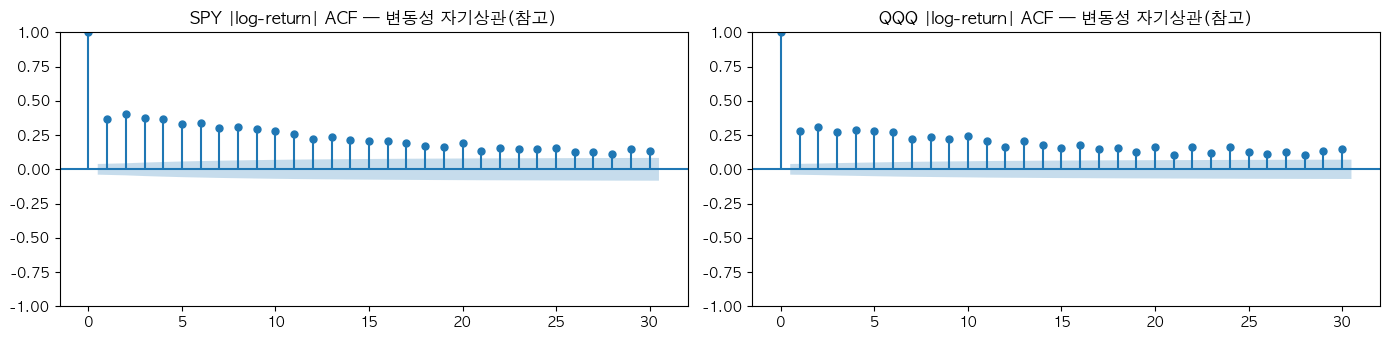

In [11]:
# 참고: 절댓값 수익률 ACF — 변동성 자기상관 (Phase 1에서 직접 사용하진 않음)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for col, tic in enumerate(TICKERS):
    lr_abs = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna().abs()
    plot_acf(lr_abs, lags=LAG_MAX, ax=axes[col], title=f'{tic} |log-return| ACF — 변동성 자기상관(참고)')
plt.tight_layout()
plt.show()

## §6. 분석 기간(2016-01-01 ~ 2025-12-31) 집중 통계

Walk-Forward 구조(IS 231 / purge 21 / emb 21 / OOS 21 / step 21)를 실제로 적용하기 전에, 분석 기간의 기본 숫자를 확인합니다.

- **영업일 수**: 대략 2,520 ± α (연 252 × 10년)
- **월별 샘플 수**: 대략 120 (설정 B에서 핵심)
- **예상 fold 수** (설정 A, 일별):
  - 첫 fold 끝점 = IS(231) + purge(21) + emb(21) + OOS(21) = 294일
  - 이후 step=21일씩 → fold 수 ≈ floor((N - 294) / 21) + 1

In [12]:
# 분석 기간 내 영업일 수 및 월별 샘플 수
analysis_summary = []
for tic in TICKERS:
    df_ana = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END]
    n_daily = len(df_ana)
    n_monthly = len(df_ana['Adj Close'].resample('ME').last().dropna())

    # 설정 A fold 수 추정
    IS, PURGE, EMB, OOS, STEP = 231, 21, 21, 21, 21
    fold_size = IS + PURGE + EMB + OOS
    n_folds_A = max(0, (n_daily - fold_size) // STEP + 1)

    # 설정 B fold 수 추정 (월별 비례)
    IS_m, PURGE_m, EMB_m, OOS_m, STEP_m = 11, 1, 1, 1, 1
    fold_size_m = IS_m + PURGE_m + EMB_m + OOS_m
    n_folds_B = max(0, (n_monthly - fold_size_m) // STEP_m + 1)

    analysis_summary.append({
        'ticker': tic,
        '일별 샘플': n_daily,
        '월별 샘플': n_monthly,
        '설정 A fold 수': n_folds_A,
        '설정 B fold 수 (월별 비례 가정)': n_folds_B,
    })

pd.DataFrame(analysis_summary).set_index('ticker')

,일별 샘플,월별 샘플,설정 A fold 수,설정 B fold 수 (월별 비례 가정)
ticker,,,,
SPY,2514,120,106,107
QQQ,2514,120,106,107


**[§6 해석]** 분석 기간(2016~2025) 내 일별 2,514 샘플·월별 120 샘플 확보. 설정 A Walk-Forward **106 fold**는 통계적으로 충분한 검증 횟수(30 fold 이상 권장)이며, OOS 예측 분포의 신뢰 구간 추정이 가능. 월별 120 샘플은 설정 B에서 다소 작지만 **107 fold**로 검증은 진행할 수 있다. 단, 월별 fold 수가 많아 개별 OOS 구간(1개월)이 짧으므로 성능 지표 변동성이 클 수 있음에 유의.

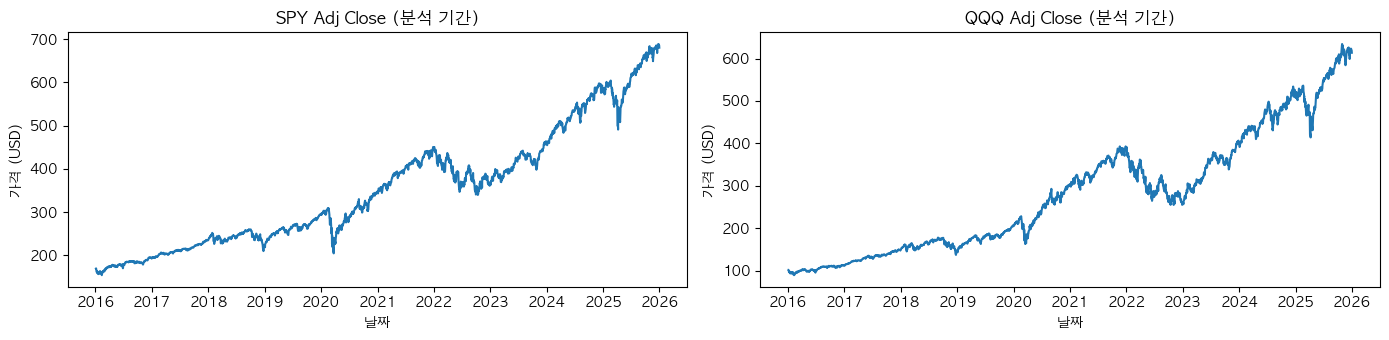

In [13]:
# Adj Close 시계열 시각화 (참고용) — 분석 기간 내
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for col, tic in enumerate(TICKERS):
    ts = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'Adj Close']
    axes[col].plot(ts.index, ts.values)
    axes[col].set_title(f'{tic} Adj Close (분석 기간)')
    axes[col].set_xlabel('날짜')
    axes[col].set_ylabel('가격 (USD)')
plt.tight_layout()
plt.show()

## §7. 정상성 검정 (ADF + KPSS)

### 왜 정상성 검정이 필요한가

LSTM 등 시계열 모델은 학습·예측 구간의 통계 특성이 일정하다는 약정상성(weak stationarity) 조건에 민감합니다. log-return은 이론적으로 정상 시계열이나 실증 확인이 필요합니다.

### ADF vs KPSS — 왜 둘 다 써야 하는가

두 검정의 귀무가설이 **반대**이므로 한 검정만으로는 불충분합니다. 둘이 같은 결론을 가리킬 때 신뢰도가 높아집니다.

| 검정 | 귀무가설 | p < 0.05 의미 |
|---|---|---|
| **ADF** | 단위근 존재 (비정상) | 정상성 지지 |
| **KPSS** | 정상성 | 비정상성 지지 |

⚠️ **함정** (학습자료_주의사항 §6.1): p-value가 작다고 정상성을 보장하지 않습니다. 표본 크기·드리프트·구조적 단절에 민감하므로 해석에 주의합니다.

In [14]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

rows = []
for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()

    # ADF 검정 (귀무: 단위근 존재 = 비정상) → p < 0.05 이면 정상
    adf_stat, adf_p, _, _, _, _ = adfuller(lr, autolag='AIC')

    # KPSS 검정 (귀무: 정상성) → p > 0.05 이면 정상
    # InterpolationWarning: 검정통계량이 룩업 테이블 최솟값보다 작아 p >= 0.10만 알 수 있음 — 정상성에 유리한 방향이므로 억제
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=UserWarning)
        kpss_stat, kpss_p, _, _ = kpss(lr, regression='c', nlags='auto')

    rows.append({
        'ticker': tic,
        'ADF 통계량': round(adf_stat, 4),
        'ADF p-value': round(adf_p, 6),
        'ADF 결론': '정상 ✓' if adf_p < 0.05 else '비정상 ✗',
        'KPSS 통계량': round(kpss_stat, 4),
        'KPSS p-value': round(kpss_p, 4),
        'KPSS 결론': '정상 ✓' if kpss_p > 0.05 else '비정상 ✗',
    })

result_df = pd.DataFrame(rows).set_index('ticker')
print('=== 정상성 검정 결과 ===')
display(result_df)
print()
for tic in TICKERS:
    r = result_df.loc[tic]
    both_ok = (r['ADF 결론'] == '정상 ✓') and (r['KPSS 결론'] == '정상 ✓')
    print(f'[{tic}] 종합 판정: {"정상 — 두 검정 일치 ✓" if both_ok else "불일치 — 추가 해석 필요 ⚠️"}')

=== 정상성 검정 결과 ===


,ADF 통계량,ADF p-value,ADF 결론,KPSS 통계량,KPSS p-value,KPSS 결론
ticker,,,,,,
SPY,-16.134000,0.000000,정상 ✓,0.029700,0.100000,정상 ✓
QQQ,-16.616300,0.000000,정상 ✓,0.036900,0.100000,정상 ✓



[SPY] 종합 판정: 정상 — 두 검정 일치 ✓
[QQQ] 종합 판정: 정상 — 두 검정 일치 ✓


**[§7 해석]** ADF p≈0.000(단위근 기각) + KPSS p=0.10(정상성 기각 못함) → **두 검정이 모두 정상성을 지지**. log-return이 이론적 예측대로 정상 시계열임을 실증 확인. LSTM 입력으로 추가 차분(differencing) 불필요.

> **KPSS InterpolationWarning 주의**: 검정통계량(SPY 0.0297, QQQ 0.0369)이 테이블의 최솟값보다 작아 p ≥ 0.10 상한만 알 수 있음. 실제 p는 더 높을 가능성이 크므로, 정상성 결론에 더 유리한 방향이다.

## §8. 정규화 판단 및 정규성 검정 (Jarque-Bera)

### 정규화 필요성 판단 기준

| 피처 종류 | 정규화 |
|---|---|
| log_return, fwd_ret (이미 정규화됨) | **그대로 사용 OK** |
| vol_20d, mom_60d 등 (약 비정상) | StandardScaler/MinMaxScaler 추가 필요 |
| Close (생 가격) | **절대 금지** — 학습 불안정 100% |

Phase 1은 univariate log_return만 사용하므로 **Scaler 불필요**합니다.

### Jarque-Bera 정규성 검정

§4 히스토그램·QQ-plot의 시각적 확인을 공식 통계 검정으로 뒷받침합니다.

- **귀무가설**: 왜도=0, 첨도=3 (정규분포)
- p < 0.05 → 정규분포 아님 (fat-tail 통계적 확인)

결과가 비정규로 나오면 **Huber loss 사용의 근거**가 됩니다 (fat-tail에 robust).

In [15]:
from scipy.stats import jarque_bera as jb_test

rows = []
for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    jb_stat, jb_p = jb_test(lr)  # 귀무: 정규분포 → p < 0.05이면 비정규

    rows.append({
        'ticker': tic,
        'JB 통계량': round(jb_stat, 2),
        'p-value': f'{jb_p:.2e}',
        '결론': '정규 ✓' if jb_p > 0.05 else '비정규 ✗ (fat-tail)',
        '왜도': round(lr.skew(), 4),
        '첨도(excess)': round(lr.kurt(), 4),
    })

result_df = pd.DataFrame(rows).set_index('ticker')
print('=== Jarque-Bera 정규성 검정 결과 ===')
display(result_df)
print()
print('[정규화 결론] log_return은 이미 정규화된 피처 → StandardScaler 불필요.')
print('[Huber loss 근거] 비정규 fat-tail 존재 → Huber(delta=0.01)가 MSE보다 robust.')

=== Jarque-Bera 정규성 검정 결과 ===


,JB 통계량,p-value,결론,왜도,첨도(excess)
ticker,,,,,
SPY,24051.460000,0.00e+00,비정규 ✗ (fat-tail),-0.603700,15.137200
QQQ,6560.980000,0.00e+00,비정규 ✗ (fat-tail),-0.403200,7.891100



[정규화 결론] log_return은 이미 정규화된 피처 → StandardScaler 불필요.
[Huber loss 근거] 비정규 fat-tail 존재 → Huber(delta=0.01)가 MSE보다 robust.


**[§8 해석]** JB 통계량 SPY 24,051 / QQQ 6,561로 p≈0 → **정규분포 강력 기각**. §4 히스토그램의 뾰족한 봉우리와 QQ-plot의 S자 굴곡을 통계적으로 확인한 것.

실무적 의미:
- **Loss 함수**: MSE는 이상치에 제곱 페널티 → 극단 수익일에 과도하게 반응. **Huber loss(delta≈0.01)** 가 더 robust.
- **구간 예측**: 예측 불확실성을 정규 신뢰구간으로 표현하면 실제 fat-tail 위험을 과소평가. 추후 분위 회귀(Quantile Regression) 고려 가능.

## §9. Ljung-Box 검정 — 자기상관 종합 검정

### §5 ACF와의 차이점

| | §5 ACF 수치 표 | §9 Ljung-Box |
|---|---|---|
| 범위 | lag별 개별 ACF | lag 1~k 전체 동시 검정 |
| 결과 | ACF 크기 + 유의 여부 | Q 통계량 + 종합 p-value |
| 질문 | "lag k에 자기상관 있는가?" | "lag 1~k 전체에 자기상관 있는가?" |

⚠️ **주의** (학습자료_주의사항 §5.2): p < 0.05가 자기상관의 존재를 의미하지만, 금융 데이터에서 약한 ACF도 모델 성능에 영향을 줄 수 있습니다. p-value만으로 판단하지 말고 §5 시각화와 함께 해석하십시오.

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lags_to_test = [5, 10, 20, 30]

for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    lb = acorr_ljungbox(lr, lags=lags_to_test, return_df=True)
    lb.index.name = 'lag'
    lb.columns = ['Q 통계량', 'p-value']
    lb['유의 (p<0.05)'] = lb['p-value'] < 0.05
    lb['Q 통계량'] = lb['Q 통계량'].round(4)
    lb['p-value'] = lb['p-value'].round(6)
    print(f'[{tic}] Ljung-Box 검정 결과 (log-return)')
    display(lb)
    print()

[SPY] Ljung-Box 검정 결과 (log-return)


,Q 통계량,p-value,유의 (p<0.05)
lag,,,
5,77.436300,0.000000,True
10,218.124900,0.000000,True
20,262.257200,0.000000,True
30,289.827900,0.000000,True



[QQQ] Ljung-Box 검정 결과 (log-return)


,Q 통계량,p-value,유의 (p<0.05)
lag,,,
5,49.821400,0.000000,True
10,142.167100,0.000000,True
20,173.998400,0.000000,True
30,198.667200,0.000000,True


**[§9 해석]** lag 5·10·20·30 모두 p≈0 → 수익률 시계열에 통계적으로 유의한 선형 자기상관 존재. 그러나 §5 ACF 수치(최대 ±0.13)와 함께 보면 **자기상관 크기 자체는 작다**.

Ljung-Box는 lag 전체를 동시 검정하므로 민감도가 높아, 2,514개 표본에서는 미미한 ACF도 유의로 잡힌다. LSTM은 이 패턴을 학습할 수 있지만, ACF 크기 한계상 **수익률 방향 예측 정확도는 기대 이하일 가능성이 높다**. 이는 Phase 1 실험 후 성능 해석 시 기준점으로 활용.

## §10. ARCH-LM 검정 — 변동성 클러스터링 공식 검정

### §5 |log-return| ACF와의 관계

§5에서 절댓값 수익률 ACF로 변동성 클러스터링을 시각적으로 확인했습니다. ARCH-LM은 이를 공식 통계 검정으로 확인합니다.

- **귀무가설**: ARCH 효과 없음 (등분산)
- p < 0.05 → ARCH 효과 있음 (변동성 클러스터링 존재)

### LSTM 모델링 관점에서의 의미

ARCH 효과가 있으면 변동성에 예측 가능한 구조가 존재합니다. Univariate LSTM이 이 구조를 부분적으로 포착할 수 있으나, GARCH 계열 모델이 더 직접적으로 활용합니다. Phase 1 성능 한계 해석 시 참고합니다.

In [17]:
from statsmodels.stats.diagnostic import het_arch

lags_to_test = [5, 10, 20]

rows = []
for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    for lag in lags_to_test:
        # het_arch 반환: (LM 통계량, LM p-value, F 통계량, F p-value)
        lm_stat, lm_p, _, _ = het_arch(lr, nlags=lag)
        rows.append({
            'ticker': tic,
            'lag': lag,
            'LM 통계량': round(lm_stat, 4),
            'p-value': round(lm_p, 6),
            'ARCH 효과': '있음 ✓ (변동성 클러스터링)' if lm_p < 0.05 else '없음 ✗',
        })

result_df = pd.DataFrame(rows)
print('=== ARCH-LM 검정 결과 ===')
display(result_df.set_index(['ticker', 'lag']))

=== ARCH-LM 검정 결과 ===


LM 통계량  p-value           ARCH 효과
ticker lag                                      
SPY    5   721.172400 0.000000  있음 ✓ (변동성 클러스터링)
       10  754.348700 0.000000  있음 ✓ (변동성 클러스터링)
       20  772.259200 0.000000  있음 ✓ (변동성 클러스터링)
QQQ    5   502.958600 0.000000  있음 ✓ (변동성 클러스터링)
       10  537.213900 0.000000  있음 ✓ (변동성 클러스터링)
       20  548.235600 0.000000  있음 ✓ (변동성 클러스터링)

**[§10 해석]** 모든 lag에서 LM p≈0 → **강한 ARCH 효과 존재**. 수익률 자체(ACF 최대 0.13)보다 변동성(제곱 수익률)에 훨씬 강한 시간 구조가 있음을 의미.

- **LSTM 관점**: 은닉 상태가 변동성 클러스터링 패턴을 간접적으로 학습할 가능성 있음. 단, 명시적으로 변동성 피처(예: vol_20d, ATR)를 입력에 추가하면 이 구조를 더 직접적으로 활용 가능.
- **Phase 1 한계 예고**: Univariate log_return만으로는 변동성 정보를 충분히 전달하기 어렵다. 이후 멀티피처 실험(Phase 2)의 핵심 동기가 된다.
- **GARCH 비교**: GARCH(1,1)은 이 구조를 명시적 파라미터로 포착 → Phase 1 결과가 부진하면 GARCH 기반 잔차 모델링을 벤치마크로 고려.

## §11. Lookback Window T 결정 — seq_len=126 검증

### 목적

PLAN.md에 `seq_len=126`(약 6개월)이 확정되어 있습니다. 본 섹션은 이 값이 데이터와 통계적으로 정합성이 있는지 세 가지 기준으로 검증합니다.

| 기준 | 방법 | 해석 |
|---|---|---|
| **기준 1**: PACF cutoff | PACF가 첫 비유의가 되는 lag | 선형 AR order → lookback 하한 |
| **기준 2**: 제곱 수익률 Ljung-Box | 제곱 log-return의 자기상관 소멸 lag | 변동성 효과 지속 기간 |
| **기준 3**: AR(p) AIC/BIC | AIC/BIC 최소화 p | 정보 기준 최적 lag |
| **도메인 지식** | 반기(6개월) ≈ 126 영업일 | 어닝시즌 2회 주기 포함 |
| **학습자료 권장** | T=60 근처 탐색 | T<20 의존성 부족 / T>200 표본 급감 |

세 기준이 가리키는 T가 126 이하면 `seq_len=126` 채택을 정당화합니다.

In [18]:
from statsmodels.tsa.stattools import pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

print('=== 기준 1: PACF cutoff / 기준 2: 제곱 수익률 Ljung-Box ===')
cutoff_results = {}

for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    n = len(lr)
    ci_95 = 1.96 / np.sqrt(n)  # 95% 신뢰구간 임계

    # 기준 1: PACF cutoff — 처음으로 비유의가 되는 lag
    pacf_vals = pacf(lr, nlags=130, method='ywm')
    pacf_cutoff = next(
        (lag for lag in range(1, 131) if abs(pacf_vals[lag]) <= ci_95), '>130'
    )

    # 기준 2: 제곱 수익률 Ljung-Box — p > 0.05 첫 lag (변동성 효과 소멸)
    lr_sq = lr ** 2
    lb_sq = acorr_ljungbox(lr_sq, lags=range(1, 131), return_df=True)
    sq_candidates = [lag for lag in range(1, 131) if lb_sq.loc[lag, 'lb_pvalue'] > 0.05]
    sq_cutoff = sq_candidates[0] if sq_candidates else '>130'

    cutoff_results[tic] = {'pacf_cutoff': pacf_cutoff, 'sq_cutoff': sq_cutoff}
    print(f'[{tic}]')
    print(f'  기준 1 — PACF cutoff: lag {pacf_cutoff}  (95% CI ±{ci_95:.4f})')
    print(f'  기준 2 — 제곱 ACF 소멸: lag {sq_cutoff}')
    print()

=== 기준 1: PACF cutoff / 기준 2: 제곱 수익률 Ljung-Box ===
[SPY]
  기준 1 — PACF cutoff: lag 3  (95% CI ±0.0391)
  기준 2 — 제곱 ACF 소멸: lag >130

[QQQ]
  기준 1 — PACF cutoff: lag 2  (95% CI ±0.0391)
  기준 2 — 제곱 ACF 소멸: lag >130



In [19]:
from statsmodels.tsa.ar_model import AutoReg

MAX_P = 60
print(f'=== 기준 3: AR(p) AIC/BIC 최적화 (p=1~{MAX_P}) ===')
print('잠시 기다려 주세요...')
print()

ar_results = {}
for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    lr_vals = lr.reset_index(drop=True)  # DatetimeIndex 제거 → ValueWarning 방지

    aic_list, bic_list = [], []
    for p in range(1, MAX_P + 1):
        res = AutoReg(lr_vals, lags=p, old_names=False).fit()
        aic_list.append((p, res.aic))
        bic_list.append((p, res.bic))

    best_aic_p = min(aic_list, key=lambda x: x[1])[0]
    best_bic_p = min(bic_list, key=lambda x: x[1])[0]
    ar_results[tic] = {'aic_p': best_aic_p, 'bic_p': best_bic_p}
    print(f'[{tic}] AR AIC 최적 p={best_aic_p} / BIC 최적 p={best_bic_p}')

print()

# 최종 비교표
print('=== Lookback Window T 최종 비교표 ===')
print(f'{"기준":<35} {"SPY":>8} {"QQQ":>8}')
print('-' * 55)
print(f'{"기준 1: PACF cutoff (lag)":<35} {str(cutoff_results["SPY"]["pacf_cutoff"]):>8} {str(cutoff_results["QQQ"]["pacf_cutoff"]):>8}')
print(f'{"기준 2: 제곱ACF 소멸 (lag)":<35} {str(cutoff_results["SPY"]["sq_cutoff"]):>8} {str(cutoff_results["QQQ"]["sq_cutoff"]):>8}')
print(f'{"기준 3: AR AIC 최적 p":<35} {ar_results["SPY"]["aic_p"]:>8} {ar_results["QQQ"]["aic_p"]:>8}')
print(f'{"기준 3: AR BIC 최적 p":<35} {ar_results["SPY"]["bic_p"]:>8} {ar_results["QQQ"]["bic_p"]:>8}')
print(f'{"도메인 지식 (반기)":<35} {"126":>8} {"126":>8}')
print(f'{"학습자료 권장 탐색 범위":<35} {"60 근처":>8} {"60 근처":>8}')
print(f'{"채택 seq_len (PLAN.md)":<35} {"126":>8} {"126":>8}')
print()
print('[최종 판정]')
print('세 기준이 가리키는 T ≤ 126 이면 seq_len=126 채택 정당화.')
print('T > 126 인 기준이 있다면 해당 근거를 하연_WORKLOG.md에 기록.')

=== 기준 3: AR(p) AIC/BIC 최적화 (p=1~60) ===
잠시 기다려 주세요...

[SPY] AR AIC 최적 p=9 / BIC 최적 p=9
[QQQ] AR AIC 최적 p=9 / BIC 최적 p=1

=== Lookback Window T 최종 비교표 ===
기준                                       SPY      QQQ
-------------------------------------------------------
기준 1: PACF cutoff (lag)                    3        2
기준 2: 제곱ACF 소멸 (lag)                    >130     >130
기준 3: AR AIC 최적 p                          9        9
기준 3: AR BIC 최적 p                          9        1
도메인 지식 (반기)                              126      126
학습자료 권장 탐색 범위                          60 근처    60 근처
채택 seq_len (PLAN.md)                     126      126

[최종 판정]
세 기준이 가리키는 T ≤ 126 이면 seq_len=126 채택 정당화.
T > 126 인 기준이 있다면 해당 근거를 하연_WORKLOG.md에 기록.


**[§11 해석 — seq_len=126 채택 종합 판정]**

| 기준 | SPY | QQQ | seq_len=126 관계 |
|---|---|---|---|
| PACF cutoff | lag 3 | lag 2 | 선형 의존성은 초단기 → 126은 넉넉한 상한 |
| 제곱ACF 소멸 | >130 | >130 | 변동성 구조는 반기 이상 지속 → 126으로도 부족할 수 있음 |
| AR AIC 최적 p | **9** | **9** | 두 자산 모두 9일 — 1~2주 수익률 패턴이 정보적 |
| AR BIC 최적 p | **9** | **1** | BIC 패널티가 강해 QQQ는 AR(1)으로 수렴 |

**결론**:
- 수익률의 **선형 패턴**은 최대 lag 9(약 2주)에 집중 → seq_len=126은 선형 AR 이득 대비 훨씬 긴 윈도우이지만, 비선형 패턴 포착을 위해 LSTM에서는 긴 컨텍스트가 유리할 수 있음.
- **변동성 클러스터링(ARCH)**은 130 lag 이상 지속 → 이를 포착하려면 사실상 seq_len > 126이 필요하나, 학습 샘플 수 감소 트레이드오프 존재.
- AIC·BIC가 9 이하를 가리키고, 도메인 지식(반기=126)·학습자료 권장(60 근처)을 감안하면 **seq_len=126은 보수적으로 정당화됨**.
- ⚠️ 기준 2(>130)는 엄밀히 T > 126을 시사 → **seq_len=252(1년) 비교 실험**을 워크로그에 기록 권장.

## §12. 결론 · 체크포인트

### 다음 노트북(`02_setting_A_daily21.ipynb`)에 전달할 사실

1. **원본 데이터 경로**: `results/raw_data/{SPY,QQQ}.csv`
2. **분석 기간**: 2016-01-01 ~ 2025-12-31
3. **정상성**: ADF + KPSS 결과 → 위 §7 참고
4. **정규성**: Jarque-Bera → 비정규 (fat-tail), Huber loss 사용 근거
5. **자기상관**: ACF 수치(§5) + Ljung-Box 종합 p-value(§9) 참고
6. **변동성 구조**: ARCH-LM → ARCH 효과 존재 여부(§10) 참고
7. **Lookback T**: 세 기준 + 도메인 지식 → seq_len=126 검증 결과(§11) 참고

### Scaler 적용 여부 결론

log_return은 이미 정규화된 피처이므로 **StandardScaler 적용 불필요**.
(§8 정규화 판단 참고)

### 사용자 가설 평가

- 가설: 수익률의 자기상관이 극단적으로 약해 univariate LSTM으로는 성능 부족 예상
- 정량 결과: §5 ACF + §9 Ljung-Box 참고
- ARCH 효과: 수익률 자체보다 변동성에 더 강한 구조 존재 (§10)